# EDA for E-commerce Recommendation System

## 1. Data Context & Schema
We will load and prepare the following datasets:
- **Interactions**: User-item interactions (views, clicks, etc.)
- **Catalog**: Product details (price, category, etc.) loaded from JSON API logs.
- **Profiles**: User demographics (age, location, etc.)

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, OneHotEncoder
from pathlib import Path
from datetime import datetime

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 2. Data Loading

In [24]:
# Define paths
DATA_DIR = Path("../data")
INTERACTIONS_PATH = DATA_DIR / "raw/batch/user_interactions"
PROFILES_PATH = DATA_DIR / "raw/batch/user_profiles"
CATALOG_PATH = DATA_DIR / "raw/api"
OUTPUT_DIR = DATA_DIR / "curated"
# Load Interactions (Parquet partitioned)
dfs = []
if INTERACTIONS_PATH.exists():
    for p in INTERACTIONS_PATH.glob("ingestion_date=*"):
        dfs.append(pd.read_parquet(p))
    df_interactions = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
else:
    df_interactions = pd.DataFrame()

# Load Profiles (Parquet partitioned)
dfs = []
if PROFILES_PATH.exists():
    for p in PROFILES_PATH.glob("ingestion_date=*"):
        dfs.append(pd.read_parquet(p))
    df_profiles = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
else:
    df_profiles = pd.DataFrame()

# Load Catalog (JSON API logs)
# Logic matched with validation script: flatten 'products' list from JSON
dfs = []
if CATALOG_PATH.exists():
    for file_path in CATALOG_PATH.rglob("products_*.json"):
        if file_path.is_file():
            try:
                data = pd.read_json(file_path)
                if "products" in data.columns:
                    dfs.append(pd.json_normalize(data["products"]))
                else:
                    dfs.append(data)
            except Exception as e:
                print(f"Error reading {file_path}: {e}")
    df_catalog = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
else:
    df_catalog = pd.DataFrame()

print("Interactions Shape:", df_interactions.shape)
print("Profiles Shape:", df_profiles.shape)
print("Catalog Shape:", df_catalog.shape)

Interactions Shape: (50007, 6)
Profiles Shape: (3000, 8)
Catalog Shape: (2000, 12)


## 3. Exploratory Data Analysis (EDA)

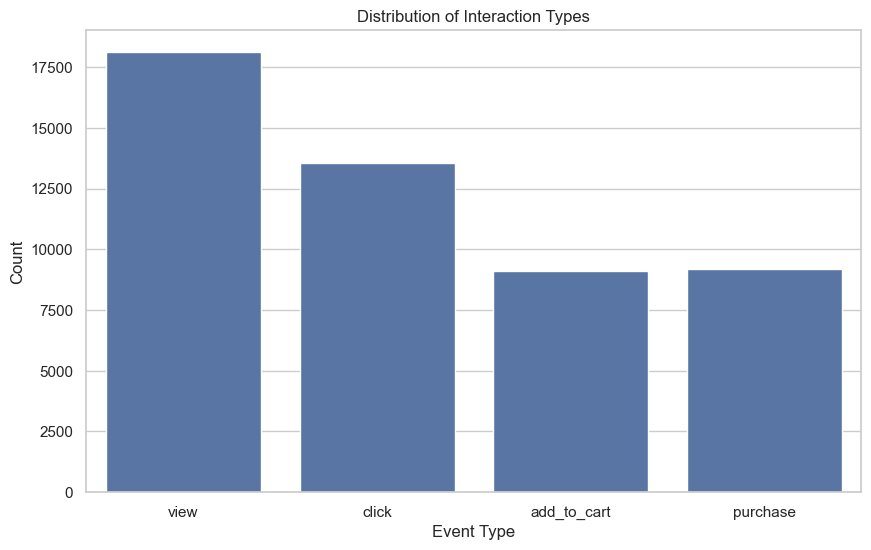

In [25]:
# 1. Interaction Distribution
plt.figure(figsize=(10, 6))
if "event_type" in df_interactions.columns:
    sns.countplot(data=df_interactions, x='event_type', order=['view', 'click', 'add_to_cart', 'purchase'])
    plt.title('Distribution of Interaction Types')
    plt.xlabel('Event Type')
    plt.ylabel('Count')
    plt.show()

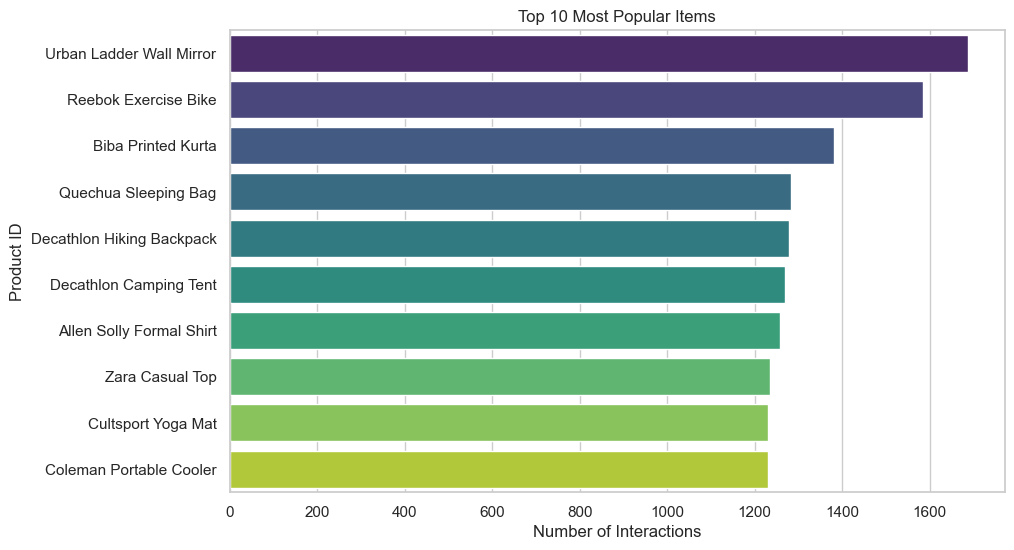

In [26]:
# 2. Item Popularity (Top 10)
df_merged = df_interactions.merge(df_catalog, on="product_id", how="left")
if "product_name" in df_merged.columns:
    top_items = df_merged['product_name'].value_counts().head(10)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_items.values, y=top_items.index, hue=top_items.index, palette="viridis", legend=False)
    plt.title('Top 10 Most Popular Items')
    plt.xlabel('Number of Interactions')
    plt.ylabel('Product ID')
    plt.show()

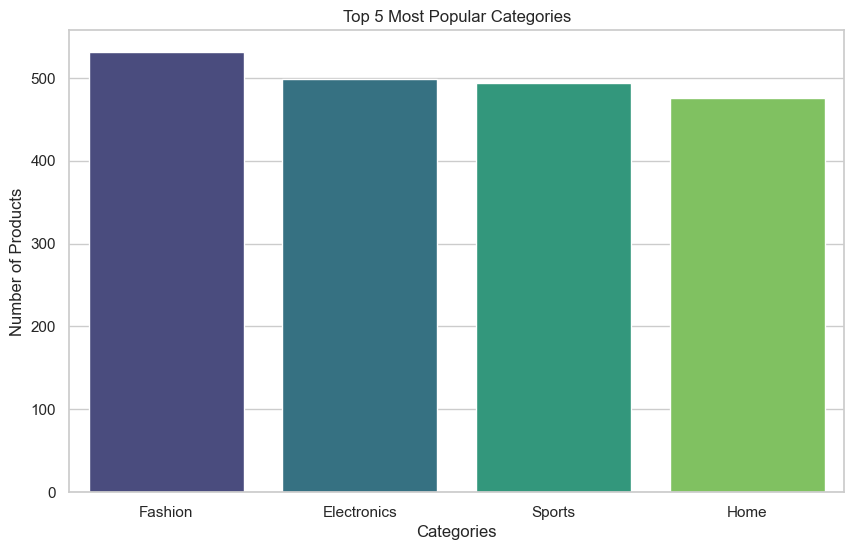

In [27]:
top_5_categories = df_catalog['category'].value_counts().head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_categories.index, y=top_5_categories.values,hue=top_5_categories.index, palette="viridis", legend=False)
plt.title('Top 5 Most Popular Categories')
plt.xlabel('Categories')
plt.ylabel('Number of Products')
plt.show()


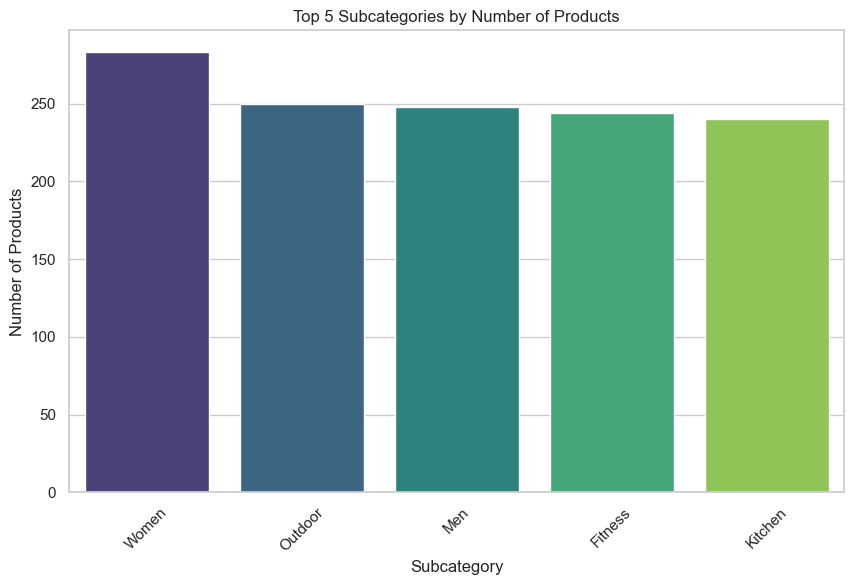

In [28]:
top_5_subcategories = df_catalog['subcategory'].value_counts().head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_subcategories.index, y=top_5_subcategories.values,hue=top_5_subcategories.index,  palette='viridis')
plt.title('Top 5 Subcategories by Number of Products')
plt.xlabel('Subcategory')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.show()

## 4. Data Cleaning & Preprocessing

In [29]:
# --- Cleaning ---
# Handle missing values
df_interactions.dropna(subset=["user_id", "product_id"], inplace=True)
df_profiles.dropna(subset=["user_id"], inplace=True)
df_catalog.dropna(subset=["product_id"], inplace=True)
df_interactions["duration_seconds"] = df_interactions["duration_seconds"].fillna(0)

# Convert IDs to categorical strings
df_interactions["user_id"] = pd.to_numeric(df_interactions["user_id"], errors='coerce').fillna(0).astype('int64')
df_interactions["product_id"] = pd.to_numeric(df_interactions["product_id"], errors='coerce').fillna(0).astype('int64')

df_profiles["user_id"] = df_profiles["user_id"].astype('int64')

df_catalog["product_id"] = pd.to_numeric(df_catalog["product_id"], errors='coerce').fillna(0).astype('int64')
if "category_id" in df_catalog.columns:
    df_catalog["category_id"] = df_catalog["category_id"].astype('int64')

print("Data types converted.")

Data types converted.


In [30]:
# --- Encoding ---
# Label Encoding for event_type
if "event_type" in df_interactions.columns:
    event_map = {"view": 1, "click": 2, "add_to_cart": 3, "purchase": 4}
    df_interactions["event_strength"] = df_interactions["event_type"].map(event_map).fillna(0).astype(int)

# One-Hot Encoding for tier (Profiles)
if "tier" in df_profiles.columns:
    df_profiles = pd.get_dummies(df_profiles, columns=["tier"], prefix="tier", dtype=int)

# One-Hot Encoding for category/subcategory (Catalog) - Keep original for EDA
if "category" in df_catalog.columns:
    cat_dummies = pd.get_dummies(df_catalog["category"], prefix="cat", dtype=int)
    df_catalog = pd.concat([df_catalog, cat_dummies], axis=1)

if "subcategory" in df_catalog.columns:
    subcat_dummies = pd.get_dummies(df_catalog["subcategory"], prefix="subcat", dtype=int)
    df_catalog = pd.concat([df_catalog, subcat_dummies], axis=1)

print("Encoding complete.")

Encoding complete.


In [31]:

# --- Normalization ---
scaler = MinMaxScaler()

# Scale price (Catalog)
if "price" in df_catalog.columns:
    df_catalog["price_scaled"] = scaler.fit_transform(df_catalog[["price"]])

# Scale age (Profiles)
if "age" in df_profiles.columns:
    df_profiles["age_scaled"] = scaler.fit_transform(df_profiles[["age"]])

# Scale duration_seconds (Interactions)
if "duration_seconds" in df_interactions.columns:
    df_interactions["duration_scaled"] = scaler.fit_transform(df_interactions[["duration_seconds"]].fillna(0))

if "stock_quantity" in df_catalog.columns:
    df_catalog["stock_quantity_scaled"] = scaler.fit_transform(df_catalog[["stock_quantity"]].fillna(0))

if "rating_count" in df_catalog.columns:
    df_catalog["rating_count_log"] = np.log1p(df_catalog["rating_count"])

# --- Timestamp Engineering ---
if "timestamp" in df_interactions.columns:
    # Convert UNIX to datetime
    df_interactions["dt"] = pd.to_datetime(df_interactions["timestamp"], unit="ns") # Assuming ns based on parquet
    # Or try infer if mixed
    # df_interactions["dt"] = pd.to_datetime(df_interactions["timestamp"])
    
    df_interactions["hour_of_day"] = df_interactions["dt"].dt.hour
    df_interactions["day_of_week"] = df_interactions["dt"].dt.dayofweek
    
    # Normalize temporal features
    df_interactions["hour_norm"] = df_interactions["hour_of_day"] / 23.0
    df_interactions["day_norm"] = df_interactions["day_of_week"] / 6.0

print("Normalization and Feature Engineering complete.")

Normalization and Feature Engineering complete.


User-Item Matrix Sparsity: 99.1660%


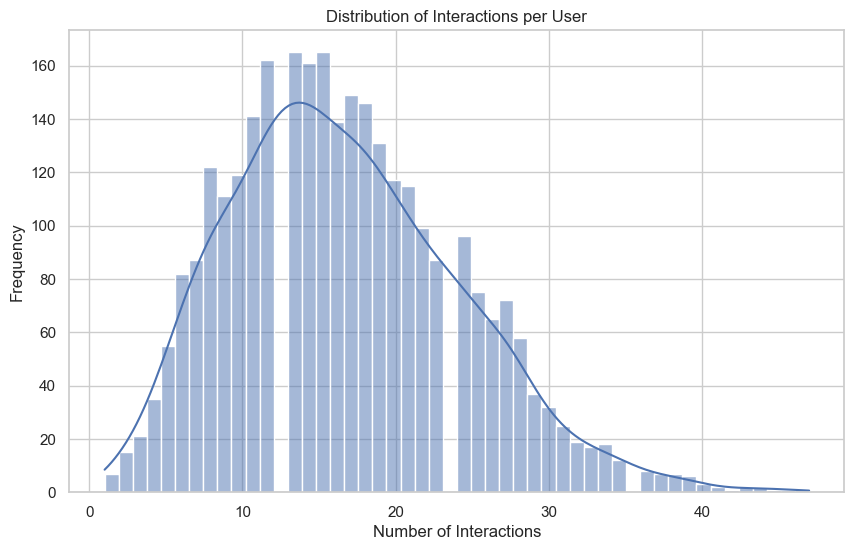

Users with < 5 interactions (Cold Start candidates): 78


In [32]:
# 3. Sparsity Pattern Analysis
n_users = df_interactions['user_id'].nunique() if "user_id" in df_interactions.columns else 0
n_items = df_interactions['product_id'].nunique() if "product_id" in df_interactions.columns else 0
n_interactions = len(df_interactions)

if n_users > 0 and n_items > 0:
    sparsity = 1 - (n_interactions / (n_users * n_items))
    print(f"User-Item Matrix Sparsity: {sparsity:.4%}")
else:
    print("Cannot calculate sparsity: Missing users or items.")

# Distribution of interactions per user
if "user_id" in df_interactions.columns:
    user_inter = df_interactions.groupby('user_id').size()

    plt.figure(figsize=(10, 6))
    sns.histplot(user_inter, bins=50, kde=True)
    plt.title('Distribution of Interactions per User')
    plt.xlabel('Number of Interactions')
    plt.ylabel('Frequency')
    plt.show()

    print("Users with < 5 interactions (Cold Start candidates):", (user_inter < 5).sum())

## 5. Final Integration

In [33]:
# Merge DataFrames
df_final = df_interactions.merge(df_profiles, on="user_id", how="left")
df_final = df_final.merge(df_catalog, on="product_id", how="left")
# Smart Filling
# 1. Identify columns to fill with median (continuous features potentially missing from joins)
impute_median_cols = ["age_scaled", "price_scaled", "rating_avg", "rating_count", "rating_count_log", "stock_quantity_scaled"]
for col in impute_median_cols:
    if col in df_final.columns:
        median_val = df_final[col].median()
        df_final[col] = df_final[col].fillna(median_val)
# 2. Fill remaining missing values with 0 (safe for one-hot encoded features and counts)
df_final.fillna(0, inplace=True)
print("Final Dataset Shape:", df_final.shape)
print("Sample:")
display(df_final.head())

Final Dataset Shape: (50007, 49)
Sample:


,user_id,session_id,product_id,event_type,timestamp,duration_seconds,event_strength,duration_scaled,dt,hour_of_day,...,subcat_Fitness,subcat_Kitchen,subcat_Laptops,subcat_Men,subcat_Mobiles,subcat_Outdoor,subcat_Women,price_scaled,stock_quantity_scaled,rating_count_log
0,2620,sess_2620_46048,1229,view,1763702039,126.44,1,0.139525,1970-01-01 00:00:01.763702039,0,...,0,0,0,1,0,0,0,0.792955,0.242485,9.114710
1,420,sess_420_87397,2386,view,1760731969,27.79,1,0.029789,1970-01-01 00:00:01.760731969,0,...,0,0,0,1,0,0,0,0.423291,0.703407,9.155673
2,896,sess_896_83563,1477,view,1764474700,631.49,1,0.701328,1970-01-01 00:00:01.764474700,0,...,0,0,0,0,0,0,1,0.088870,0.362725,8.525558
3,1719,sess_1719_87236,1452,view,1763143377,683.17,1,0.758816,1970-01-01 00:00:01.763143377,0,...,0,0,0,0,0,0,0,0.086594,0.569138,8.419801
4,1719,sess_1719_87236,1452,click,1763143422,628.63,2,0.698147,1970-01-01 00:00:01.763143422,0,...,0,0,0,0,0,0,0,0.086594,0.569138,8.419801


### 6. Correlation Analysis
We calculate correlation coefficients to identify relationships between numeric features and encoded categorical features.

Correlation Matrix:
                  duration_seconds       age     price  rating_avg
duration_seconds          1.000000 -0.006911  0.002044    0.001603
age                      -0.006911  1.000000 -0.010119    0.003080
price                     0.002044 -0.010119  1.000000   -0.030366
rating_avg                0.001603  0.003080 -0.030366    1.000000


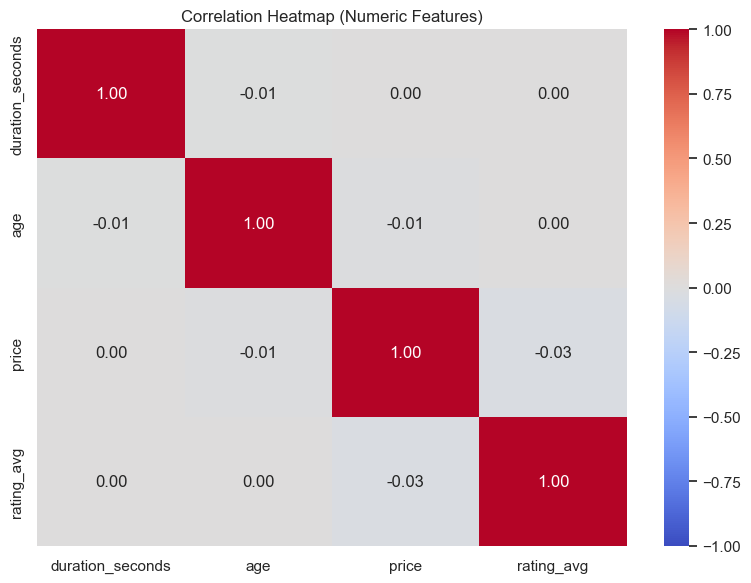

In [34]:
# Select numeric columns for correlation
numeric_cols = ['duration_seconds', 'age', 'price', 'rating_avg']
cols_to_use = [c for c in numeric_cols if c in df_final.columns]

if cols_to_use:
    corr_matrix = df_final[cols_to_use].corr()
    print("Correlation Matrix:")
    print(corr_matrix)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
    plt.title('Correlation Heatmap (Numeric Features)')
    plt.tight_layout()
    plt.show()
else:
    print('No numeric columns found for correlation.')